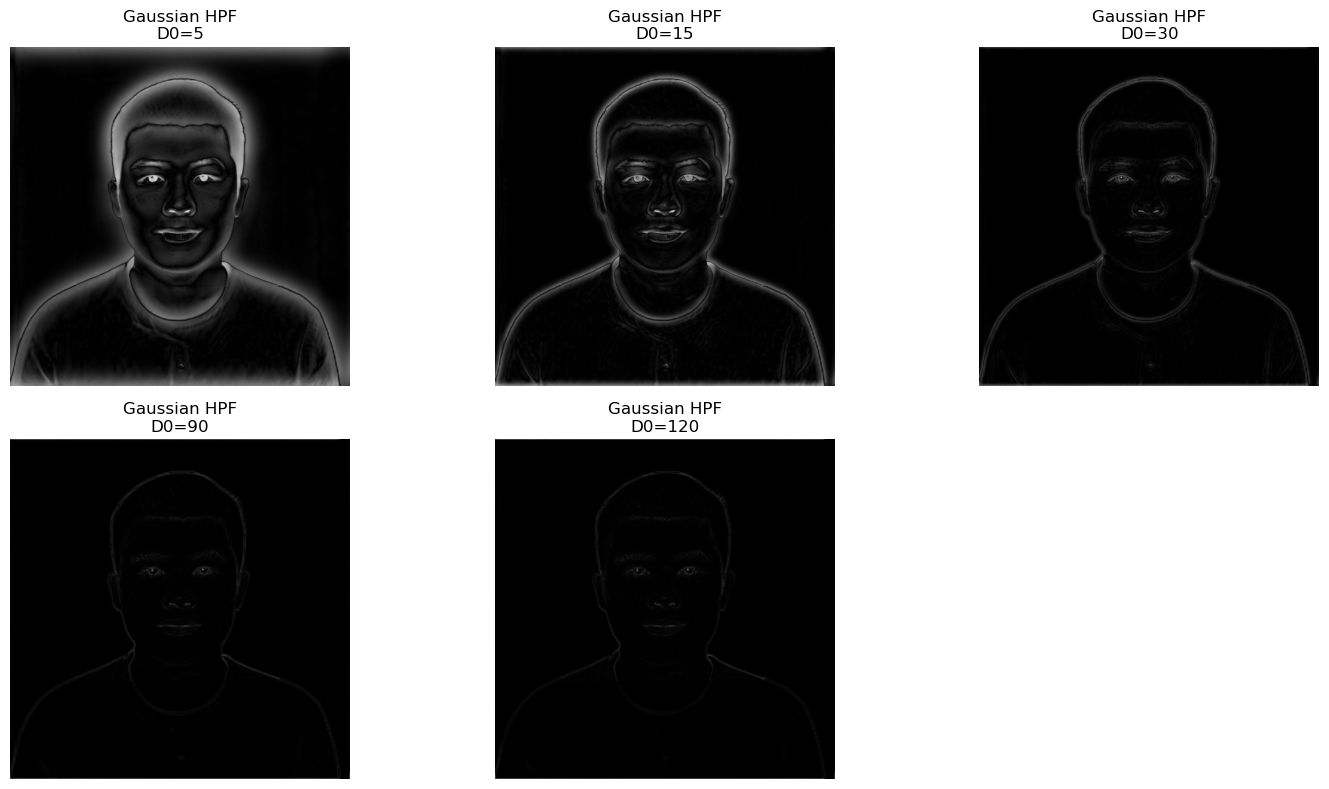

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def gaussian_high_pass_filter(shape, D0):
    rows, cols = shape
    u = np.arange(rows) - rows // 2
    v = np.arange(cols) - cols // 2
    U, V = np.meshgrid(v, u)
    D = np.sqrt(U**2 + V**2)
    H = 1 - np.exp(-(D**2) / (2 * (D0**2)))
    return H

def apply_filter(img, H):
    dft = np.fft.fft2(img)
    dft_shift = np.fft.fftshift(dft)
    filtered = dft_shift * H
    back_ishift = np.fft.ifftshift(filtered)
    img_back = np.fft.ifft2(back_ishift)
    return np.abs(img_back)

img_path = r"D:\AP22110010458\digital-image-preprocessing\assets\photo.jpg"
img = cv2.imread(img_path, 0)

if img is None:
    raise FileNotFoundError(f"Image not found at: {img_path}")

cutoffs = [5, 15, 30, 90, 120]

plt.figure(figsize=(15, 8))
for i, D0 in enumerate(cutoffs):
    H = gaussian_high_pass_filter(img.shape, D0)
    filtered_img = apply_filter(img, H)
    plt.subplot(2, 3, i+1)
    plt.imshow(filtered_img, cmap='gray')
    plt.title(f'Gaussian HPF\nD0={D0}')
    plt.axis('off')

plt.tight_layout()
plt.show()
